In [1]:
import os
from collections import Counter

import torch
import matplotlib.pyplot as plt

from torch_geometric.datasets import QM9, ZINC
from torch_geometric.loader import DataLoader
import torch_geometric.utils as utils

from rdkit import Chem
from rdkit.Chem import AllChem, Draw

# Notebook display helpers
try:
    from IPython.display import display
    import py3Dmol
    HAS_NOTEBOOK = True
except Exception:
    HAS_NOTEBOOK = False

print(HAS_NOTEBOOK)

True


### 1) Load datasets (PyG)

In [2]:

ROOT = os.path.expanduser("data/pyg_molecules")

qm9 = QM9(root=os.path.join(ROOT, "QM9"))
# ZINC in PyG is a common benchmark subset (not the full ZINC database).
# "subset=True" gives the standard smaller version.
zinc_train = ZINC(root=os.path.join(ROOT, "ZINC"), split="train", subset=True)
zinc_val   = ZINC(root=os.path.join(ROOT, "ZINC"), split="val", subset=True)
zinc_test  = ZINC(root=os.path.join(ROOT, "ZINC"), split="test", subset=True)

# qm9.process()
print("QM9:", len(qm9), "molecules")
# zinc_train.process()
print("ZINC subset:", len(zinc_train), "train,", len(zinc_val), "val,", len(zinc_test), "test")

print("\nQM9 sample keys:", qm9[0].keys())
print(qm9[1000].y.shape)
print(qm9[1000].edge_attr)
print(qm9[1000].keys)
print(qm9[1000].x)
print(qm9[1000].edge_index)
print(utils.to_dense_adj(qm9[1000].edge_index))

# QM9 usually has: z (atomic numbers), pos (3D coords), edge_index, edge_attr, y (targets)
# ZINC usually has: x (atom type one-hot or index-like), edge_index, edge_attr, y (property), NO 3D coords by default
# print("\nZINC sample keys:", zinc_train[0].keys())

QM9: 130831 molecules
ZINC subset: 10000 train, 1000 val, 1000 test

QM9 sample keys: ['y', 'x', 'idx', 'name', 'smiles', 'pos', 'edge_attr', 'edge_index', 'z']
torch.Size([1, 19])
tensor([[0., 1., 0., 0.],
        [0., 1., 0., 0.],
        [1., 0., 0., 0.],
        [1., 0., 0., 0.],
        [1., 0., 0., 0.],
        [0., 1., 0., 0.],
        [1., 0., 0., 0.],
        [0., 1., 0., 0.],
        [1., 0., 0., 0.],
        [1., 0., 0., 0.],
        [1., 0., 0., 0.],
        [0., 1., 0., 0.],
        [0., 1., 0., 0.],
        [1., 0., 0., 0.],
        [1., 0., 0., 0.],
        [1., 0., 0., 0.],
        [1., 0., 0., 0.],
        [1., 0., 0., 0.],
        [1., 0., 0., 0.],
        [1., 0., 0., 0.],
        [1., 0., 0., 0.],
        [1., 0., 0., 0.]])
<bound method BaseData.keys of Data(x=[11, 11], edge_index=[2, 22], edge_attr=[22, 4], y=[1, 19], pos=[11, 3], z=[11], smiles='[H]C(=O)C1=C([H])N=C([H])N1[H]', name='gdb_1027', idx=[1])>
tensor([[0., 0., 0., 1., 0., 8., 0., 0., 0., 0., 0.],
     

### 2) Quick dataset exploration plots

In [3]:
def summarize_dataset(ds, name, n=2000):
    n = min(n, len(ds))
    num_nodes = []
    num_edges = []
    has_pos = 0

    for i in range(n):
        d = ds[i]
        num_nodes.append(int(d.num_nodes))
        num_edges.append(int(d.num_edges))
        has_pos += int(hasattr(d, "pos") and d.pos is not None)

    print(f"\n{name} summary on first {n} samples:")
    print(f"  avg nodes: {sum(num_nodes)/len(num_nodes):.2f}  |  avg edges: {sum(num_edges)/len(num_edges):.2f}")
    print(f"  has 3D pos: {has_pos}/{n}")

    plt.figure()
    plt.hist(num_nodes, bins=30)
    plt.title(f"{name}: #atoms (#nodes)")
    plt.xlabel("#atoms")
    plt.ylabel("count")
    plt.show()

    plt.figure()
    plt.hist(num_edges, bins=30)
    plt.title(f"{name}: #bonds-edges (#edges in edge_index)")
    plt.xlabel("#edges")
    plt.ylabel("count")
    plt.show()

summarize_dataset(qm9, "QM9", n=len(qm9))
# summarize_dataset(zinc_train, "ZINC (train subset)", n=len(zinc_train))

KeyboardInterrupt: 

#### RDkit helpers - for visualization

In [4]:
d = zinc_train[0]
print(d.keys())
print("x shape:", d.x.shape, "dtype:", d.x.dtype, "min/max:", int(d.x.min()), int(d.x.max()))
print("y shape:", d.y.shape, "dtype:", d.y.dtype, "min/max:", int(d.y.min()), int(d.y.max()))
print(d.edge_index.shape)
print("edge_attr shape:", None if d.edge_attr is None else d.edge_attr.shape)
print("edge_attr min/max:\n", d.edge_attr.min(), d.edge_attr.max())

['edge_attr', 'y', 'x', 'edge_index']
x shape: torch.Size([29, 1]) dtype: torch.int64 min/max: 0 5
y shape: torch.Size([1]) dtype: torch.float32 min/max: 0 0
torch.Size([2, 64])
edge_attr shape: torch.Size([64])
edge_attr min/max:
 tensor(1) tensor(2)


In [4]:
# -----------------------------
# ZINC: exact maps you provided
# -----------------------------
# Node label index -> (symbol, formal_charge, explicit_H_count)
ZINC_NODE = {
    0:  ("C",  0, 0),
    1:  ("O",  0, 0),
    2:  ("N",  0, 0),
    3:  ("F",  0, 0),
    4:  ("C",  0, 1),   # C H1
    5:  ("S",  0, 0),
    6:  ("Cl", 0, 0),
    7:  ("O", -1, 0),   # O -
    8:  ("N", +1, 1),   # N H1 +
    9:  ("Br", 0, 0),
    10: ("N", +1, 3),   # N H3 +
    11: ("N", +1, 2),   # N H2 +
    12: ("N", +1, 0),   # N +
    13: ("N", -1, 0),   # N -
    14: ("S", -1, 0),   # S -
    15: ("I",  0, 0),
    16: ("P",  0, 0),
    17: ("O", +1, 1),   # O H1 +
    18: ("N", -1, 1),   # N H1 -
    19: ("O", +1, 0),   # O +
    20: ("S", +1, 0),   # S +
    21: ("P",  0, 1),   # P H1
    22: ("P",  0, 2),   # P H2
    23: ("C", -1, 2),   # C H2 -
    24: ("P", +1, 0),   # P +
    25: ("S", +1, 1),   # S H1 +
    26: ("C", -1, 1),   # C H1 -
    27: ("P", +1, 1),   # P H1 +
}

# Edge labels (bond order): SINGLE=1, DOUBLE=2, TRIPLE=3
ZINC_BOND = {
    1: Chem.BondType.SINGLE,
    2: Chem.BondType.DOUBLE,
    3: Chem.BondType.TRIPLE,
}

# -----------------------------
# QM9 maps (as you provided)
# -----------------------------
QM9_NODE = {0: "H", 1: "C", 2: "N", 3: "O", 4: "F"}
QM9_BOND = {
    0: Chem.BondType.SINGLE,
    1: Chem.BondType.DOUBLE,
    2: Chem.BondType.TRIPLE,
    3: Chem.BondType.AROMATIC,
}

def _as_1d_long(x: torch.Tensor) -> torch.Tensor:
    if x is None:
        return None
    if x.dim() == 2 and x.size(1) == 1:
        x = x.view(-1)
    return x.long().view(-1)

def _unique_undirected_edges(edge_index: torch.Tensor, edge_attr: torch.Tensor | None):
    """
    Keep only one direction per undirected edge (i<j).
    Returns (pairs, attrs) where:
      pairs: list[(i,j)]
      attrs: list[attr_row] or None
    """
    ei = edge_index.long()
    seen = set()
    pairs = []
    attrs = [] if edge_attr is not None else None

    E = ei.size(1)
    for k in range(E):
        i = int(ei[0, k].item())
        j = int(ei[1, k].item())
        if i == j:
            continue
        a, b = (i, j) if i < j else (j, i)
        if (a, b) in seen:
            continue
        seen.add((a, b))
        pairs.append((a, b))
        if attrs is not None:
            attrs.append(edge_attr[k])

    return pairs, attrs

# =========================
# ZINC: PyG Data -> RDKit
# =========================
def pyg_zinc_to_rdkit(data, sanitize=True) -> Chem.Mol:
    """
    Expects:
      - data.x: integer node labels 0..27 (shape [N] or [N,1])
      - data.edge_attr: integer bond labels 1..3 (shape [E] or [E,1] or [E,k] with bond label in col 0)
    """
    x = _as_1d_long(data.x)
    if x is None:
        raise ValueError("ZINC conversion expects data.x with node labels 0..27.")

    rw = Chem.RWMol()
    for idx in x.tolist():
        if idx not in ZINC_NODE:
            raise ValueError(f"Unknown ZINC node label {idx}. Expected 0..27.")
        sym, charge, hcount = ZINC_NODE[int(idx)]
        atom = Chem.Atom(sym)
        atom.SetFormalCharge(int(charge))
        # ZINC label encodes explicit H count. Tell RDKit explicitly.
        if hcount > 0:
            atom.SetNumExplicitHs(int(hcount))
            atom.SetNoImplicit(True)  # don't let RDKit add implicit H on top
        rw.AddAtom(atom)

    # bonds
    ea = getattr(data, "edge_attr", None)
    if ea is None:
        raise ValueError("ZINC conversion expects data.edge_attr with bond labels 1..3.")

    ea = ea.long()
    if ea.dim() == 2:
        bond_label = ea[:, 0]  # exact: first column is bond type label (1..3)
    else:
        bond_label = ea.view(-1)

    pairs, attrs = _unique_undirected_edges(data.edge_index, bond_label)

    for (i, j), bl in zip(pairs, attrs):
        bl = int(bl.item())
        if bl not in ZINC_BOND:
            raise ValueError(f"Unknown ZINC edge label {bl}. Expected 1,2,3.")
        rw.AddBond(int(i), int(j), ZINC_BOND[bl])

    mol = rw.GetMol()
    if sanitize:
        # if this fails, the graph really is inconsistent with the valence/charge labels
        Chem.SanitizeMol(mol)
    return mol

# =========================
# QM9: PyG Data -> RDKit
# =========================
def pyg_qm9_to_rdkit(data, sanitize=True, use_pos=False) -> Chem.Mol:
    """
    Supports two common QM9 encodings:
      A) PyG QM9: data.z = atomic numbers, data.pos = coords
      B) Your mapping: data.x integer labels 0..4 (H,C,N,O,F)
    Bonds:
      - edge_attr scalar in {0..3} or one-hot over 4; aromatic allowed.
    """
    rw = Chem.RWMol()

    if hasattr(data, "z") and data.z is not None:
        z = _as_1d_long(data.z)
        for zi in z.tolist():
            rw.AddAtom(Chem.Atom(int(zi)))
    else:
        x = _as_1d_long(data.x)
        if x is None:
            raise ValueError("QM9 conversion expects data.z (atomic numbers) or data.x (0..4 atom labels).")
        for t in x.tolist():
            sym = QM9_NODE[int(t)]
            rw.AddAtom(Chem.Atom(sym))

    ea = getattr(data, "edge_attr", None)
    if ea is None:
        # QM9 sometimes omits explicit bond types; default to single
        bond_label = None
    else:
        ea = ea.long()
        if ea.dim() == 2 and ea.size(-1) > 1:
            bond_label = ea.argmax(dim=-1)  # one-hot over {0..3}
        elif ea.dim() == 2 and ea.size(-1) == 1:
            bond_label = ea[:, 0]
        else:
            bond_label = ea.view(-1)

    pairs, attrs = _unique_undirected_edges(data.edge_index, bond_label)

    for (i, j), bl in zip(pairs, attrs):
        bt = QM9_BOND[int(bl.item())] if bl is not None else Chem.BondType.SINGLE
        rw.AddBond(int(i), int(j), bt)

    mol = rw.GetMol()
    if sanitize:
        Chem.SanitizeMol(mol)

    if use_pos and hasattr(data, "pos") and data.pos is not None:
        pos = data.pos.detach().cpu().float()
        conf = Chem.Conformer(mol.GetNumAtoms())
        for idx in range(mol.GetNumAtoms()):
            x, y, z = pos[idx].tolist()
            conf.SetAtomPosition(idx, (float(x), float(y), float(z)))
        mol.RemoveAllConformers()
        mol.AddConformer(conf, assignId=True)

    return mol

# =========================
# 3D embedding (generic)
# =========================
def rdkit_embed_3d(mol: Chem.Mol, seed=0, max_iters=200) -> Chem.Mol:
    """
    Robust conformer generation.
    Assumes mol is chemically valid (sanitize succeeded).
    """
    mol = Chem.AddHs(mol)
    params = AllChem.ETKDGv3()
    params.randomSeed = int(seed)

    ok = AllChem.EmbedMolecule(mol, params)
    if ok != 0:
        # fallback
        ok = AllChem.EmbedMolecule(mol, randomSeed=int(seed))

    if ok == 0:
        try:
            AllChem.UFFOptimizeMolecule(mol, maxIters=int(max_iters))
        except Exception:
            pass

    mol = Chem.RemoveHs(mol)
    return mol


def show_2d(mol, size=(300, 300)):
    img = Draw.MolToImage(mol, size=size)
    if HAS_NOTEBOOK:
        display(img)
    else:
        # script fallback
        plt.figure()
        plt.imshow(img)
        plt.axis("off")
        plt.show()


def show_3d(mol, style="stick"):
    if not HAS_NOTEBOOK:
        print("3D visualization works best in a notebook (py3Dmol).")
        return
    mb = Chem.MolToMolBlock(mol)
    view = py3Dmol.view(width=420, height=320)
    view.addModel(mb, "mol")
    view.setStyle({style: {}})
    view.zoomTo()
    return view.show()

### 4) Visualize


QM9 example (has 3D coords):


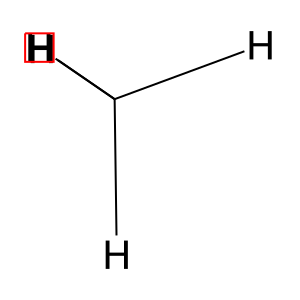

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

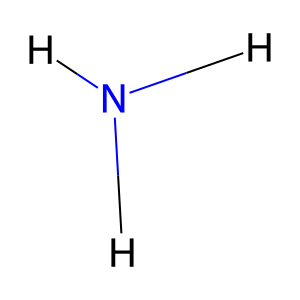

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

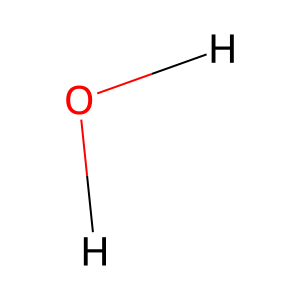

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

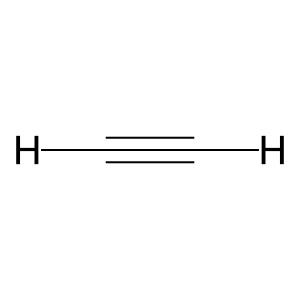

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

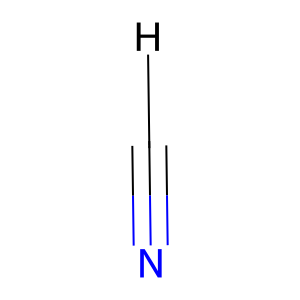

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

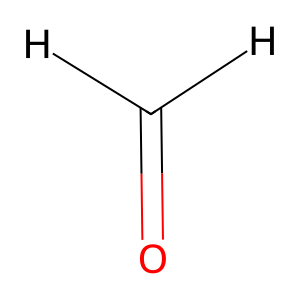

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

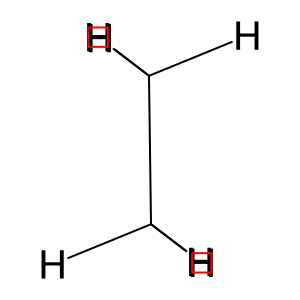

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

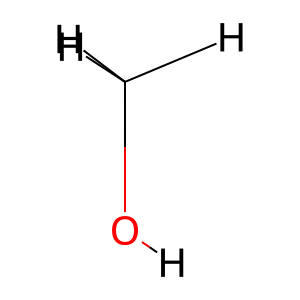

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

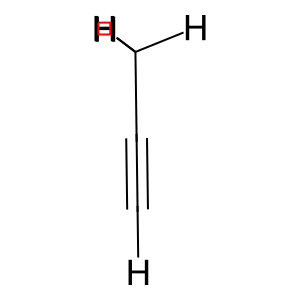

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

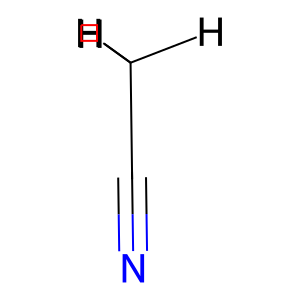

3Dmol.js failed to load for some reason. Please check your browser console for error messages.


ZINC example (no 3D coords by default):


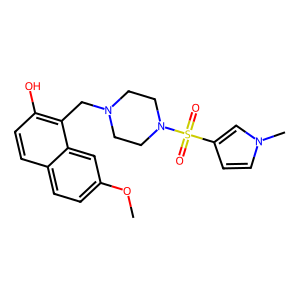

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

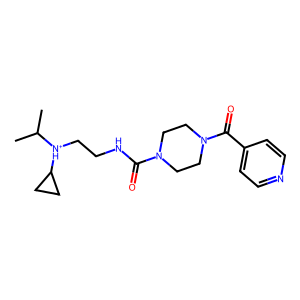

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

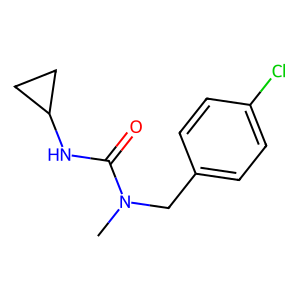

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

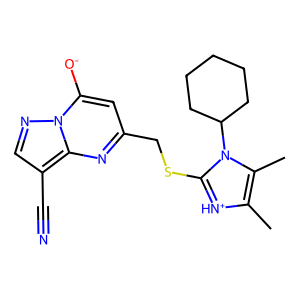

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

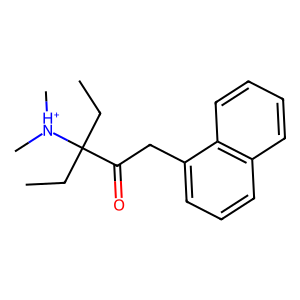

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

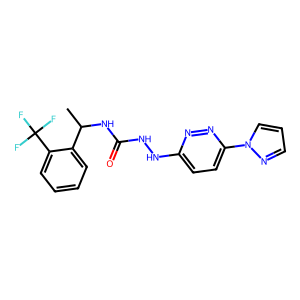

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

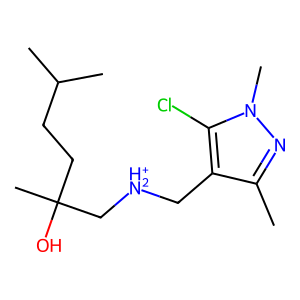

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

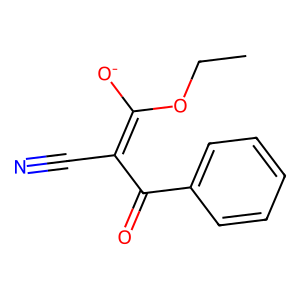

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

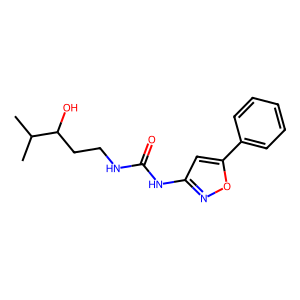

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

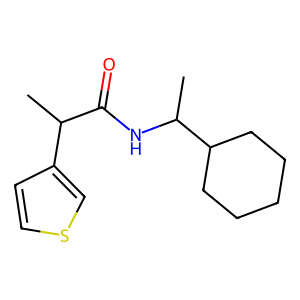

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

In [5]:
print("\nQM9 example (has 3D coords):")
for qm9_ex in qm9[:10]:
    qm9_mol = pyg_qm9_to_rdkit(qm9_ex, sanitize=True, use_pos=True)
    show_2d(qm9_mol)
    show_3d(qm9_mol)  # shows QM9 ground-truth-ish coords from dataset

print("\nZINC example (no 3D coords by default):")
for zinc_ex in zinc_train[:10]:
    zinc_mol = pyg_zinc_to_rdkit(zinc_ex, sanitize=True)
    show_2d(zinc_mol)
    zinc_mol_3d = rdkit_embed_3d(zinc_mol, seed=42)
    show_3d(zinc_mol_3d)  # RDKit-generated conformer

## 5) How to use these for (A) discrete generation and (B) joint discrete+3D generation

### ---- A) Discrete Molecular Generation (graph only) ----
Typical discrete state:
   - node categorical types (atom identity)
   - edge categorical types (bond identity) on some edge set

#### For QM9:
   - node types = data.z (atomic numbers)  [N]
   - bonds = data.edge_index, data.edge_attr (categorical bond types)

#### For ZINC:
   - node types from data.x (one-hot or integer-coded)
   - bonds from edge_index + edge_attr

In [7]:
def discrete_state_from_pyg(data, dataset=None):
    # Node types:
    if hasattr(data, "z") and data.z is not None:
        node_type = data.z.long().view(-1)  # atomic numbers
    else:
        # if one-hot, convert to indices
        x = data.x
        node_type = x.argmax(dim=-1).long() if x.dim() == 2 and x.size(-1) > 1 else x.long().view(-1)

    # Edge types (bond categories)
    edge_index = data.edge_index.long()
    edge_attr = getattr(data, "edge_attr", None)
    if edge_attr is None:
        edge_type = torch.zeros(edge_index.size(1), dtype=torch.long)
    else:
        edge_type = edge_attr.argmax(dim=-1).long() if edge_attr.dim() == 2 and edge_attr.size(-1) > 1 else edge_attr.long().view(-1)

    return {
        "node_type": node_type,         # [N] categorical
        "edge_index": edge_index,       # [2, E]
        "edge_type": edge_type,         # [E] categorical
    }

qm9_disc = discrete_state_from_pyg(qm9[0], dataset=qm9)
zinc_disc = discrete_state_from_pyg(zinc_train[0], dataset=zinc_train)

print("\nDiscrete state shapes:")
print("QM9:", {k: tuple(v.shape) for k, v in qm9_disc.items()})
print("ZINC:", {k: tuple(v.shape) for k, v in zinc_disc.items()})

# In a VFM / CatFlow style setup:
#   - node_type and edge_type are modeled on a simplex (categorical distribution per node/edge)
#   - your model predicts a vector field / flow in that simplex space (or logits -> flow, depending on formulation)



Discrete state shapes:
QM9: {'node_type': (5,), 'edge_index': (2, 8), 'edge_type': (8,)}
ZINC: {'node_type': (29,), 'edge_index': (2, 64), 'edge_type': (64,)}


### ---- B) Joint Molecular Generation (discrete graph + 3D coordinates) ----
- QM9 gives you 3D coordinates directly: data.pos [N, 3]
- ZINC does not (by default), so "joint generation" usually uses a dataset with conformers or you generate initial 3D coords yourself (RDKit, etc.) and treat coords as continuous variables.

In [8]:
def joint_state_from_pyg(data, dataset=None):
    disc = discrete_state_from_pyg(data, dataset=dataset)
    if hasattr(data, "pos") and data.pos is not None:
        pos = data.pos.float()  # [N, 3]
    else:
        pos = None
    return {**disc, "pos": pos}

print(qm9[0].edge_attr)
qm9_joint = joint_state_from_pyg(qm9[0], dataset=qm9)
zinc_joint = joint_state_from_pyg(zinc_train[0], dataset=zinc_train)

print("\nJoint state:")
print("QM9 pos:", None if qm9_joint["pos"] is None else tuple(qm9_joint["pos"].shape))
print("ZINC pos:", zinc_joint["pos"])

# In a VFM setup for JOINT generation:
#   - discrete part: node/edge categories (simplex dynamics)
#   - continuous part: positions pos ∈ R^{N×3} (Euclidean dynamics)
#   - model backbone: Graph Transformer / EGNN / equivariant transformer
#   - training: match vector fields for both components, often with shared message passing


tensor([[1., 0., 0., 0.],
        [1., 0., 0., 0.],
        [1., 0., 0., 0.],
        [1., 0., 0., 0.],
        [1., 0., 0., 0.],
        [1., 0., 0., 0.],
        [1., 0., 0., 0.],
        [1., 0., 0., 0.]])

Joint state:
QM9 pos: (5, 3)
ZINC pos: None


### 6) Mini-batching example (what your training loop actually consumes)


In [9]:
from my_utils import batch_to_dense

qm9_loader = DataLoader(qm9, batch_size=32, shuffle=True)
zinc_loader = DataLoader(zinc_train, batch_size=32, shuffle=True)

qm9_batch = next(iter(qm9_loader))
zinc_batch = next(iter(zinc_loader))

print(type(qm9_batch))
batch_ready = batch_to_dense(qm9_batch)

print("\nBatch shapes:")
print("QM9 batch:",
      "num_nodes =", qm9_batch.num_nodes,
      "| edge_index =", tuple(qm9_batch.edge_index.shape),
      "| pos =", tuple(qm9_batch.pos.shape) if hasattr(qm9_batch, "pos") else None,
      "| z =", tuple(qm9_batch.z.shape) if hasattr(qm9_batch, "z") else None)

print("ZINC batch:",
      "num_nodes =", zinc_batch.num_nodes,
      "| edge_index =", tuple(zinc_batch.edge_index.shape),
      "| x =", tuple(zinc_batch.x.shape) if hasattr(zinc_batch, "x") else None)

# Tip for generation models:
# - qm9_batch.batch gives node->graph assignment for batching.
# - If your model is fixed-max-N (common in graph diffusion/flow papers), you’ll typically pad within each batch.
# - If your model supports variable N (message passing usually does), you can keep ragged graphs and use 'batch'.



<class 'abc.DataBatch'>

Batch shapes:
QM9 batch: num_nodes = 566 | edge_index = (2, 1176) | pos = (566, 3) | z = (566,)
ZINC batch: num_nodes = 769 | edge_index = (2, 1650) | x = (769, 1)


### 7) A tiny “generation-ready” extraction: adjacency with bond types (discrete)


In [10]:
def edge_list_to_bond_matrix(node_type, edge_index, edge_type, num_bond_types=4):
    """
    Creates a dense [N, N] matrix of bond type indices, with 0 meaning 'no bond' by convention.
    WARNING: For large N this is expensive; for molecules it's fine.
    """
    N = int(node_type.numel())
    bond = torch.zeros((N, N), dtype=torch.long)
    for k in range(edge_index.size(1)):
        i = int(edge_index[0, k])
        j = int(edge_index[1, k])
        bt = int(edge_type[k])
        # clamp to expected range
        bt = max(0, min(bt, num_bond_types - 1))
        bond[i, j] = bt + 1  # shift by 1 so 0 is "no bond"
    # symmetrize
    bond = torch.maximum(bond, bond.T)
    return bond

d = qm9[0]
disc = discrete_state_from_pyg(d, dataset=qm9)
bond_mat = edge_list_to_bond_matrix(disc["node_type"], disc["edge_index"], disc["edge_type"])
print("\nExample bond matrix shape:", tuple(bond_mat.shape), "| unique entries:", torch.unique(bond_mat).tolist())

# This is the kind of representation many discrete graph generators use:
#   node categories + (optional) dense bond-type adjacency
# For joint models, you carry pos alongside.

print("\nDone. You now have:")
print(" - dataset loading (QM9, ZINC)")
print(" - dataset exploration plots")
print(" - PyG -> RDKit conversion")
print(" - 2D and 3D visualization")
print(" - discrete vs joint state extraction that maps cleanly onto VFM/CatFlow + EGNN style models")


Example bond matrix shape: (5, 5) | unique entries: [0, 1]

Done. You now have:
 - dataset loading (QM9, ZINC)
 - dataset exploration plots
 - PyG -> RDKit conversion
 - 2D and 3D visualization
 - discrete vs joint state extraction that maps cleanly onto VFM/CatFlow + EGNN style models
